In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

In [101]:
os.chdir('.../outputs_miscellaneous')

v_vs = np.load('ANHA4-EJM010_JLS_v_2004-2017.npz')
v_vs = v_vs['vomecrty']

v_vd = np.load('ANHA4-EJM012_JLS_v_2004-2017.npz')
v_vd = v_vd['vomecrty']

u_vs = np.load('ANHA4-EJM010_NS_u_2004-2017.npz')
u_vs = u_vs['vozocrtx']

u_vd = np.load('ANHA4-EJM012_NS_u_2004-2017.npz')
u_vd = u_vd['vozocrtx']

In [64]:
os.chdir('.../')

mesh = xr.open_dataset('ANHA4_mesh_zgr.nc')

e1v = mesh['e1v']    # for jones/lancaster sound
e2u = mesh['e2u']    # for nares strait
e3t = mesh['e3t_0']

In [65]:
lat_jls = 535
lon_jls = np.arange(160, 195)

lat_ns = np.arange(530, 550)
lon_ns = 230

dpt = np.arange(0, 32)

In [89]:
slice_e2u = e2u[0, lat_ns, lon_ns]
slice_e2u = 32*[slice_e2u]

np.shape(slice_e1v)

(32, 35)

In [93]:
len(slice_e2u[1])

20

In [102]:
##Nares Strait

slice_e2u = e2u[0, lat_ns, lon_ns]
slice_e2u = 32*[slice_e2u]

e3t_u = e3t[0, 0:32]
e3t_u = len(slice_e2u[1])*[e3t_u]
e3t_u = np.transpose(e3t_u)

u_vs = u_vs[:, 0:32, :]
u_vd = u_vd[:, 0:32, :]

u_vs[np.where(u_vs > 0)] = np.nan
u_vd[np.where(u_vd > 0)] = np.nan

vt_u_vs = []
vt_u_vd = []

for day in range(len(u_vs)):
    mult1 = np.multiply(u_vs[day], slice_e2u)
    mult2 = np.multiply(mult1, e3t_u)
    vt_sum = np.nansum(mult2)/1e6
    vt_u_vs.append(vt_sum)

for day in range(len(u_vd)):
    mult1 = np.multiply(u_vd[day], slice_e2u)
    mult2 = np.multiply(mult1, e3t_u)
    vt_sum = np.nansum(mult2)/1e6
    vt_u_vd.append(vt_sum)

vt_u_vs = np.array(vt_u_vs)
vt_u_vd = np.array(vt_u_vd)

dif_ns = vt_u_vd - vt_u_vs

In [104]:
##Jones/Lancaster sound

slice_e1v = e1v[0, lat_jls, lon_jls]

slice_e1v = 32*[slice_e1v]

e3t_v = e3t[0, 0:32]
e3t_v = 35*[e3t_v]
e3t_v = np.transpose(e3t_v)

v_vs = v_vs[:, 0:32, :]
v_vd = v_vd[:, 0:32, :]

v_vs[np.where(v_vs > 0)] = np.nan
v_vd[np.where(v_vd > 0)] = np.nan

vt_v_vs = []
vt_v_vd = []

for day in range(len(v_vs)):
    mult1 = np.multiply(v_vs[day], slice_e1v)
    mult2 = np.multiply(mult1, e3t_v)
    vt_sum = np.nansum(mult2)/1e6
    vt_v_vs.append(vt_sum)

for day in range(len(v_vd)):
    mult1 = np.multiply(v_vd[day], slice_e1v)
    mult2 = np.multiply(mult1, e3t_v)
    vt_sum = np.nansum(mult2)/1e6
    vt_v_vd.append(vt_sum)

vt_v_vs = np.array(vt_v_vs)
vt_v_vd = np.array(vt_v_vd)

dif_jls = vt_v_vd - vt_v_vs

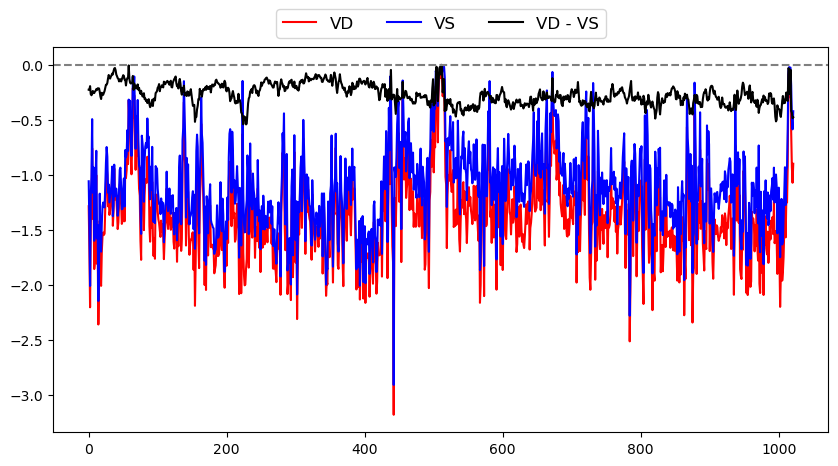

In [107]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(vt_u_vd, color='red')
plt.plot(vt_u_vs, color='blue')
plt.plot(dif_ns, color='black')
plt.legend(['VD', 'VS', 'VD - VS'], fontsize=12, loc='upper center', bbox_to_anchor=(0.5,1.12), ncol=3)
plt.axhline(y=0, color='grey', linestyle='--')

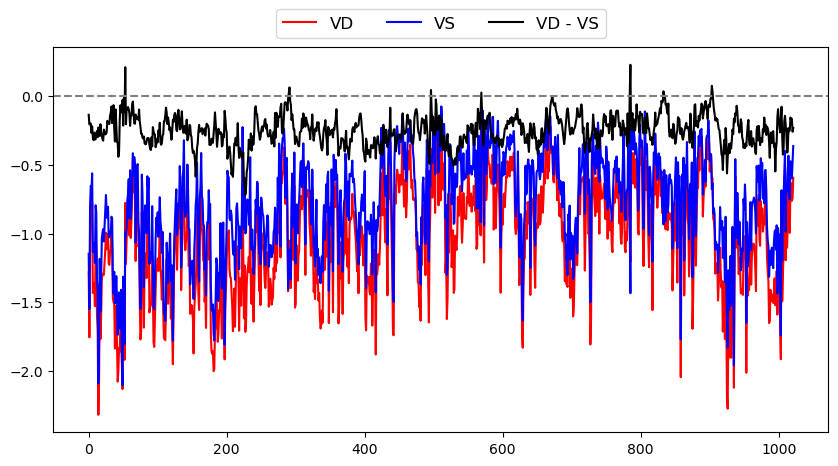

In [106]:
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(vt_v_vd, color='red')
plt.plot(vt_v_vs, color='blue')
plt.plot(dif_jls, color='black')
plt.legend(['VD', 'VS', 'VD - VS'], fontsize=12, loc='upper center', bbox_to_anchor=(0.5,1.12), ncol=3)
plt.axhline(y=0, color='grey', linestyle='--')

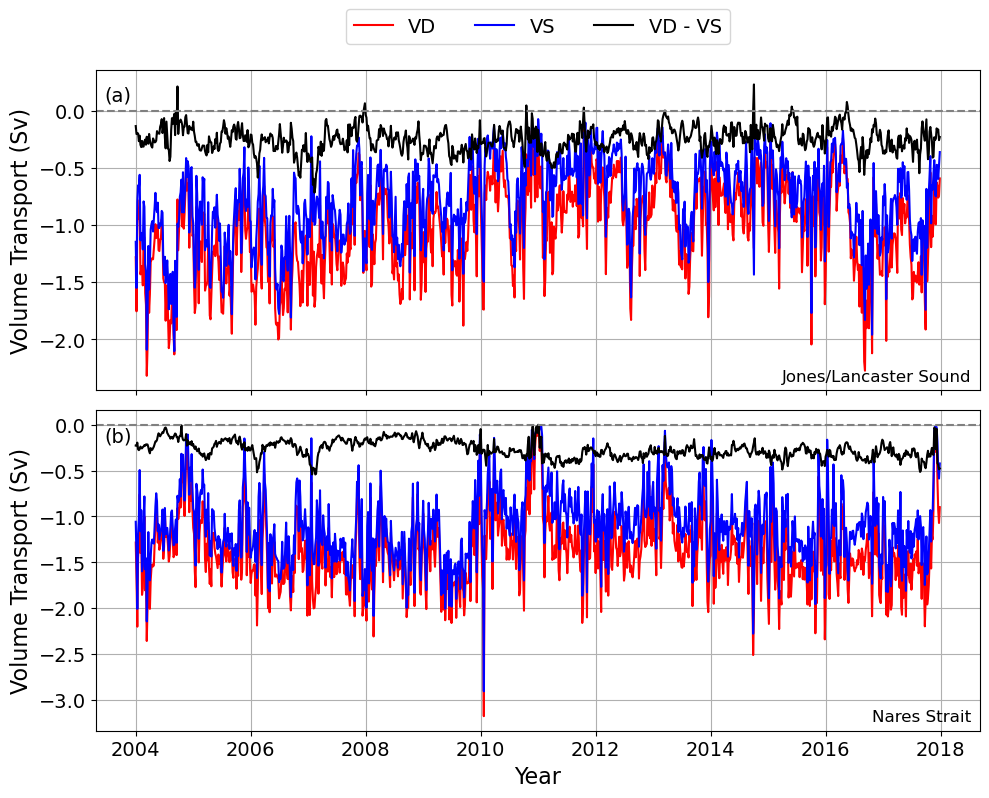

In [131]:
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(10, 8), sharex=True)

axes[0].plot(vt_v_vd, color='red')
axes[0].plot(vt_v_vs, color='blue')
axes[0].plot(dif_jls, color='black')
axes[0].axhline(y=0, color='grey', linestyle='--')
axes[0].grid(True)

axes[0].tick_params(axis='y', labelsize=14)
axes[0].set_ylabel('Volume Transport (Sv)', fontsize = 16)

axes[0].legend(['VD', 'VS', 'VD - VS'], fontsize=14, loc='upper center', bbox_to_anchor=(0.5, 1.22), ncol=3)

axes[0].text(0.01, 0.95, '(a)', transform=axes[0].transAxes, fontsize=14, va='top')

axes[1].plot(vt_u_vd, color='red')
axes[1].plot(vt_u_vs, color='blue')
axes[1].plot(dif_ns, color='black')

axes[1].axhline(y=0, color='grey', linestyle='--')
axes[1].grid(True)

axes[1].tick_params(axis='y', labelsize=14)
axes[1].set_ylabel('Volume Transport (Sv)', fontsize = 16)
axes[1].set_xlabel('Year', fontsize = 16)

axes[1].text(0.01, 0.95, '(b)', transform=axes[1].transAxes, fontsize=14, va='top')


axes[0].text(0.99, 0.02, 'Jones/Lancaster Sound', transform=axes[0].transAxes, ha='right', va='bottom', fontsize=12)
axes[1].text(0.99, 0.02, 'Nares Strait', transform=axes[1].transAxes, ha='right', va='bottom', fontsize=12)

year_ticks = np.arange(0, 1095, 73 * 2)
year_labels = np.arange(2004, 2019, 2)

axes[1].set_xticks(year_ticks)
axes[1].set_xticklabels(year_labels, fontsize = 14)

plt.tight_layout()

outdir = '.../Figure8_JLS_NS_VolumeTransport'

plt.savefig(os.path.join(outdir, 'Volume_Transport_JLS_NS.png'), dpi=300, bbox_inches='tight')

plt.show()